In [1]:
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from src.callback import TrainingCallback, env_callback

In [2]:
env = env_callback()
n_actions = env.action_space.shape[-1]
vec_env = make_vec_env(env_callback, n_envs=8)

model = A2C(
    "MlpPolicy",
    vec_env,
    learning_rate=0.01,
    verbose=0,
    tensorboard_log="results",
)

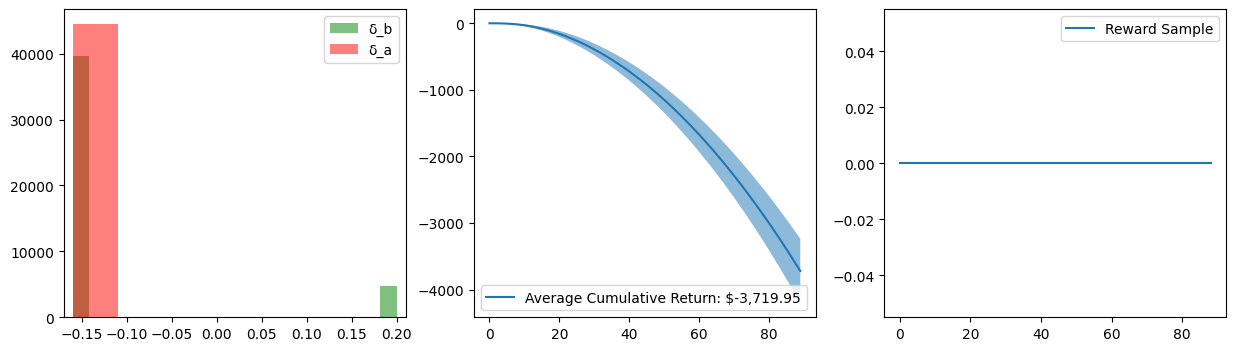


Timestep: 15000


In [3]:
# to load already trained model
# model = A2C.load("models/A2C_utility_optimal")
# model.env = vec_env

model.learn(
    total_timesteps=2000000,
    callback=[
        TrainingCallback(100, env),
        CheckpointCallback(1000, "models", name_prefix="A2C"),
    ],
)